In [32]:
txt = '''
Für die Evaluation fokussiere ich mich auf die Power-Consumption-Features
(shunt_voltage, bus_voltage_V, current_mA, power_mW), da diese als
standardisierte Messgrößen in der Ladeinfrastruktur vorliegen und direkt
über die OCPP-Schnittstelle erfasst werden. Um realistische Unterschiede
zwischen physisch getrennten EVSE-Einheiten zu simulieren, werden die
synthetischen Knoten durch einen state-spezifischen Bias-Offset (idle vs.
charging) und einen Timestamp-Jitter individualisiert. Diese Individuali-
sierung modelliert systematische Sensorabweichungen durch Kalibrierungs-
toleranzen und konstante Netzwerklatenzen — zwei physikalisch motivierte
Quellen inter-node Varianz in realen Ladeinfrastrukturen.
'''

print(txt)


Für die Evaluation fokussiere ich mich auf die Power-Consumption-Features
(shunt_voltage, bus_voltage_V, current_mA, power_mW), da diese als
standardisierte Messgrößen in der Ladeinfrastruktur vorliegen und direkt
über die OCPP-Schnittstelle erfasst werden. Um realistische Unterschiede
zwischen physisch getrennten EVSE-Einheiten zu simulieren, werden die
synthetischen Knoten durch einen state-spezifischen Bias-Offset (idle vs.
charging) und einen Timestamp-Jitter individualisiert. Diese Individuali-
sierung modelliert systematische Sensorabweichungen durch Kalibrierungs-
toleranzen und konstante Netzwerklatenzen — zwei physikalisch motivierte
Quellen inter-node Varianz in realen Ladeinfrastrukturen.



In [33]:
import pandas as pd
import numpy as np

# =============================================================================
# LOAD DATASET
# Source : CICEVSE2024 — CIC EV Charger Attack Dataset 2024
# Node   : EVSE-B (the only physical node available in this dataset)
# File   : EVSE-B-PowerCombined.csv — Power Consumption features only
# Reason : Power features (shunt_voltage, bus_voltage_V, current_mA, power_mW)
#          are used as the sole input for ML training and synthetic node
#          generation. Network/packet features are excluded.
# =============================================================================

df_power = pd.read_csv('../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv')

for name, df in [('Power-Consumption', df_power)]:
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:", df.isnull().sum().sum())
    print()

=== Power-Consumption ===
Shape: (115298, 10)
Columns: ['time', 'shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State', 'Attack', 'Attack-Group', 'Label', 'interface']
Missing values: 0



In [34]:
txt = '''
- Blocklänge: 3-Minuten-Fenster (aligned to ML feature extraction window)
- Abhängigkeit innerhalb eines Blocks: Hard cut at day boundaries,
  kein Cross-Day oder Cross-Segment Mixing (7 Segmente, 5-Tage-Gap beachtet)
- Überlappung: keine (disjoint blocks only, kein Sliding Window)
- Gruppierung: 10-20 aufeinanderfolgende Blöcke mit gleichem Attack-Label
  vor einem Label-Wechsel (simuliert realistische Attack-Runs von 30-60 Min)
- Anzahl synthetischer Knoten: 8 (1 real + 8 synthetic = 9 Knoten gesamt)
  → ermöglicht Echo-Chamber Sweep von M:K = 1:8 bis 8:1
- Bootstrap-Strategie: intra-node (nur EVSE-B als Quelle, with replacement)
  → cross-node und cluster-basiert nicht anwendbar (nur 1 physischer Knoten)
- Bekannte Limitation: alle synthetischen Knoten teilen dieselbe
  Grundverteilung (EVSE-B), Inter-Node Diversität nur durch
  Bias-Offset und Timestamp-Jitter
'''
print(txt)


- Blocklänge: 3-Minuten-Fenster (aligned to ML feature extraction window)
- Abhängigkeit innerhalb eines Blocks: Hard cut at day boundaries,
  kein Cross-Day oder Cross-Segment Mixing (7 Segmente, 5-Tage-Gap beachtet)
- Überlappung: keine (disjoint blocks only, kein Sliding Window)
- Gruppierung: 10-20 aufeinanderfolgende Blöcke mit gleichem Attack-Label
  vor einem Label-Wechsel (simuliert realistische Attack-Runs von 30-60 Min)
- Anzahl synthetischer Knoten: 8 (1 real + 8 synthetic = 9 Knoten gesamt)
  → ermöglicht Echo-Chamber Sweep von M:K = 1:8 bis 8:1
- Bootstrap-Strategie: intra-node (nur EVSE-B als Quelle, with replacement)
  → cross-node und cluster-basiert nicht anwendbar (nur 1 physischer Knoten)
- Bekannte Limitation: alle synthetischen Knoten teilen dieselbe
  Grundverteilung (EVSE-B), Inter-Node Diversität nur durch
  Bias-Offset und Timestamp-Jitter



In [35]:
# =============================================================================
# DAY SEGMENT ANALYSIS
# Purpose : Identify non-chronological segments and temporal gaps in EVSE-B.
#           This analysis is the justification for HARD_CUT_DAY_BOUNDARY = True.
#
# Finding : The dataset contains 7 non-chronological day segments and a
#           5-day gap (2023-12-25 to 2023-12-30). Segments are recording
#           sessions, not a continuous time series.
#
# Consequence : Blocks must never cross segment boundaries — a 3-minute block
#               spanning two segments would mix temporally unrelated rows,
#               introducing artificial patterns into the bootstrap.
#               This would corrupt both ML training and evaluation validity.
# =============================================================================

import pandas as pd

df_power['time'] = pd.to_datetime(df_power['time'])
df_power['date_only'] = df_power['time'].dt.date

jump_mask    = df_power['date_only'] != df_power['date_only'].shift(1)
jump_indices = df_power[jump_mask].index.tolist()

print("=" * 75)
print("LOCATING DAY JUMPS IN THE DATASET")
print("=" * 75)

for i, start_idx in enumerate(jump_indices):
    current_date = df_power.loc[start_idx, 'date_only']

    if i + 1 < len(jump_indices):
        end_idx      = jump_indices[i + 1] - 1
        next_date    = df_power.loc[jump_indices[i + 1], 'date_only']
        days_skipped = (next_date - current_date).days
    else:
        end_idx      = len(df_power) - 1
        days_skipped = 0

    row_count = end_idx - start_idx + 1

    print(f"Segment {i+1}: Date {current_date}")
    print(f"  -> Span: Row Index {start_idx:,} to {end_idx:,} ({row_count:,} data points)")

    if days_skipped > 1:
        print(f"  ⚠️ JUMP DETECTED: {days_skipped} days missing before {next_date}!")
    print("-" * 75)

df_power.drop(columns=['date_only'], inplace=True)

LOCATING DAY JUMPS IN THE DATASET
Segment 1: Date 2023-12-25
  -> Span: Row Index 0 to 4,929 (4,930 data points)
---------------------------------------------------------------------------
Segment 2: Date 2023-12-26
  -> Span: Row Index 4,930 to 13,516 (8,587 data points)
---------------------------------------------------------------------------
Segment 3: Date 2023-12-25
  -> Span: Row Index 13,517 to 34,883 (21,367 data points)
---------------------------------------------------------------------------
Segment 4: Date 2023-12-26
  -> Span: Row Index 34,884 to 60,842 (25,959 data points)
---------------------------------------------------------------------------
Segment 5: Date 2023-12-24
  -> Span: Row Index 60,843 to 87,568 (26,726 data points)
---------------------------------------------------------------------------
Segment 6: Date 2023-12-25
  -> Span: Row Index 87,569 to 94,160 (6,592 data points)
  ⚠️ JUMP DETECTED: 5 days missing before 2023-12-30!
--------------------------

In [36]:
# =============================================================================
# BLOCK SIZE ANALYSIS
# Purpose : Empirically determine the optimal block size for bootstrap.
#           Tests all interval sizes from 1 min to 120 min with hard day cuts.
#
# Decision : 3-minute blocks chosen because:
#   1. Aligned to ML feature extraction window (3-min = one Threat-Report)
#   2. 664 blocks available — sufficient pool for bootstrap with replacement
#   3. Avg 173 rows/block — enough statistical signal per window for ML
#   4. Min 26 rows/block — acceptable lower bound (tail blocks at day edges)
#
# This table is the empirical justification for BOOTSTRAP_BLOCK_MIN = 3.
# Any other block size would decouple the bootstrap unit from the ML unit,
# requiring separate justification.
# =============================================================================

import numpy as np

# 1. Convert time column to datetime format
df_power['time'] = pd.to_datetime(df_power['time'])

# 2. Extract the date component to group by day boundaries
df_power['date_only'] = df_power['time'].dt.date

# Group by the natural day blocks (preserving chronological order)
day_groups = df_power.groupby('date_only', sort=False)

# Define the intervals
minute_intervals = [0, 1, 2, 3] + list(range(5, 121, 5)) + [1000]

# --- PRINT NOTEBOOK HEADER / EXPLANATION ---
txt = "Blocklänge oder Regel zur blockbildung"
print("=" * 75)
print(f"RESEARCH QUESTION : {txt}")
print(f"RULE              : Hard cut at day boundaries applied (No cross-day mixing).")
print("=" * 75)
print()

print(f"{'Interval':<12} | {'Block Count':<12} | {'Avg Rows/Block':<16} | {'Min Rows':<10} | {'Max Rows':<10}")
print("-" * 75)

total_rows = len(df_power)

for min_value in minute_intervals:
    if min_value == 0:
        # 0 Min: Every single row is its own block
        print(f"{'0 Min (Raw)':<12} | {total_rows:<12,} | {1.0:<16.1f} | {1:<10} | {1:<10}")
        
    else:
        all_blocks_for_interval = []
        
        # Process each day independently to enforce the hard cut rule
        for day, day_segment in day_groups:
            # Step A: Count rows per unique minute inside *this specific day*
            rows_per_minute_in_day = day_segment.groupby('time', sort=False).size().tolist()
            
            if min_value == 1:
                # 1 Min: The blocks are simply the individual minute groups of this day
                all_blocks_for_interval.extend(rows_per_minute_in_day)
            else:
                # For > 1 Min: Chunk the minute groups of THIS day only
                for i in range(0, len(rows_per_minute_in_day), min_value):
                    chunk = rows_per_minute_in_day[i:i + min_value]
                    all_blocks_for_interval.append(sum(chunk))
                    
        # Calculate statistics across all safe, boundary-respecting blocks
        block_count = len(all_blocks_for_interval)
        avg_rows = np.mean(all_blocks_for_interval)
        min_rows = np.min(all_blocks_for_interval)
        max_rows = np.max(all_blocks_for_interval)
        
        print(f"{f'{min_value} Min':<12} | {block_count:<12,} | {avg_rows:<16.1f} | {min_rows:<10} | {max_rows:<10}")

# Clean up helper column
df_power.drop(columns=['date_only'], inplace=True)

RESEARCH QUESTION : Blocklänge oder Regel zur blockbildung
RULE              : Hard cut at day boundaries applied (No cross-day mixing).

Interval     | Block Count  | Avg Rows/Block   | Min Rows   | Max Rows  
---------------------------------------------------------------------------
0 Min (Raw)  | 115,298      | 1.0              | 1          | 1         
1 Min        | 1,995        | 57.8             | 8          | 59        
2 Min        | 998          | 115.5            | 8          | 117       
3 Min        | 666          | 173.1            | 26         | 175       
5 Min        | 401          | 287.5            | 23         | 291       
10 Min       | 201          | 573.6            | 116        | 582       
15 Min       | 134          | 860.4            | 313        | 872       
20 Min       | 102          | 1130.4           | 116        | 1163      
25 Min       | 81           | 1423.4           | 698        | 1453      
30 Min       | 68           | 1695.6           | 313    

In [37]:
# =============================================================================
# BLOCK DEPENDENCY & TEMPORAL INTEGRITY
# =============================================================================
# All rows within a 3-minute block must originate from the same continuous
# day segment. The dataset contains non-chronological segments and a 5-day
# gap (2023-12-25 to 2023-12-30), making hard cuts at day boundaries
# a strict requirement to prevent temporal leakage between blocks.

HARD_CUT_DAY_BOUNDARY = True  # no cross-day or cross-segment mixing
BOOTSTRAP_BLOCK_MIN   = 3     # aligned to ML feature extraction window

# =============================================================================
# OVERLAP STRATEGY
# =============================================================================
# Block formation uses disjoint (non-overlapping) cuts.
# Bootstrap resampling draws blocks with replacement, which is overlap-free
# by construction. No sliding window is applied at the block level.

OVERLAP = False  # disjoint blocks only

# =============================================================================
# GROUPED BOOTSTRAP — ATTACK RUN LENGTH
# =============================================================================
# To avoid unrealistic label fragmentation (attack type switching every 3 min),
# consecutive blocks are drawn from the same attack label before switching.
# This produces attack runs of 30-60 minutes (~1730-3460 rows), consistent
# with the temporal structure observed in EVSE-B where each attack type
# persists for extended periods before transitioning.

MIN_CONSECUTIVE_BLOCKS = 10  # minimum 30 min per attack run
MAX_CONSECUTIVE_BLOCKS = 20  # maximum 60 min per attack run

# =============================================================================
# NODE COUNT & REAL-TO-SYNTHETIC RATIO
# =============================================================================
# To empirically test the Echo-Chamber effect, the compromised majority (M)
# must be sweepable from minority to supermajority against correct nodes (K).
# 9 nodes (1 real + 8 synthetic) provide a full M:K sweep from 1:8 to 8:1,
# covering all tipping points of the weighted aggregation variants.

N_REAL_NODES      = 1  # EVSE-B only
N_SYNTHETIC_NODES = 8  # 9 nodes total → M:K sweep from 1:8 to 8:1

# =============================================================================
# BOOTSTRAP STRATEGY
# =============================================================================
# Only one physical node (EVSE-B) is available, so cross-node or
# cluster-based bootstrap is not applicable. Each synthetic node is generated
# by drawing blocks with replacement from the 664-block pool of EVSE-B
# (intra-node bootstrap). This is a known limitation: all synthetic nodes
# share the same underlying distribution, reducing inter-node diversity.
# This limitation is relevant to the Echo-Chamber robustness analysis and
# should be acknowledged as a constraint on external validity.

BOOTSTRAP_STRATEGY = "intra-node"  # single-source, drawing with replacement

In [38]:
# =============================================================================
# BUILD BLOCK POOL
# Purpose : Construct the actual 3-minute block pool used for bootstrap.
#           Applies HARD_CUT_DAY_BOUNDARY — each block stays within one
#           day segment. Incomplete tail blocks (< 3 min) are dropped.
#
# Result  : 664 blocks, avg 173.5 rows/block (min 102, max 175)
#           This pool is the single source for all synthetic node generation.
# =============================================================================

HARD_CUT_DAY_BOUNDARY = True
BOOTSTRAP_BLOCK_MIN   = 3
OVERLAP               = False
N_REAL_NODES          = 1
N_SYNTHETIC_NODES     = 8
MIN_CONSECUTIVE_BLOCKS = 10
MAX_CONSECUTIVE_BLOCKS = 20

df_power['time']      = pd.to_datetime(df_power['time'])
df_power['date_only'] = df_power['time'].dt.date

blocks = []

for day, day_df in df_power.groupby('date_only', sort=False):
    day_df      = day_df.reset_index(drop=True)
    minute_list = [grp for _, grp in day_df.groupby(
        day_df['time'].dt.floor('min'), sort=False
    )]
    for i in range(0, len(minute_list), BOOTSTRAP_BLOCK_MIN):
        chunk = minute_list[i:i + BOOTSTRAP_BLOCK_MIN]
        if len(chunk) == BOOTSTRAP_BLOCK_MIN:
            blocks.append(pd.concat(chunk).reset_index(drop=True))

df_power.drop(columns=['date_only'], inplace=True)

BLOCK_POOL_SIZE = len(blocks)
print(f"Block pool size : {BLOCK_POOL_SIZE} blocks")
print(f"Avg rows/block  : {np.mean([len(b) for b in blocks]):.1f}")
print(f"Min rows/block  : {min(len(b) for b in blocks)}")
print(f"Max rows/block  : {max(len(b) for b in blocks)}")

Block pool size : 664 blocks
Avg rows/block  : 173.5
Min rows/block  : 102
Max rows/block  : 175


In [39]:
# =============================================================================
# BLOCK BOOTSTRAP — GROUPED NODE GENERATION
# Purpose : Generate synthetic nodes with realistic attack run lengths.
#
# Problem with naive bootstrap: drawing blocks independently produces a new
# attack label every 3 minutes (~173 rows), which does not reflect the
# original EVSE-B structure where each attack type persists for extended
# periods (30-120 min). This fragmentation would make the coordinated global
# event injection (Evaluation 2a) indistinguishable from random label overlap.
#
# Solution: Draw 10-20 consecutive blocks of the same attack label before
# switching. This produces attack runs of ~30-60 minutes (~1730-3460 rows),
# consistent with the temporal structure of EVSE-B (9 unique runs total).
#
# Known limitation: label distribution may deviate slightly from the original
# 87.5% / 12.5% split due to random label selection. Documented per node
# in the verification table below.
# =============================================================================

def generate_synthetic_node_grouped(
    block_pool: list,
    seed: int,
    min_consecutive: int = 10,
    max_consecutive: int = 20
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    label_pools = {}
    for block in block_pool:
        dominant_label = block['Attack'].mode()[0]
        if dominant_label not in label_pools:
            label_pools[dominant_label] = []
        label_pools[dominant_label].append(block)

    label_list    = list(label_pools.keys())
    target_rows   = sum(len(b) for b in block_pool)
    result_blocks = []
    total_rows    = 0

    while total_rows < target_rows:
        chosen_label = label_list[int(rng.integers(0, len(label_list)))]
        pool = label_pools[chosen_label]

        n = int(rng.integers(min_consecutive, max_consecutive + 1))
        for _ in range(n):
            idx = int(rng.integers(0, len(pool)))
            result_blocks.append(pool[idx].copy())
            total_rows += len(pool[idx])
            if total_rows >= target_rows:
                break

    df = pd.concat(result_blocks).reset_index(drop=True)
    return df.iloc[:target_rows].reset_index(drop=True)


# =============================================================================
# GENERATE
# =============================================================================

synthetic_nodes = {
    f"synthetic_{i+1}": generate_synthetic_node_grouped(
        block_pool=blocks,
        seed=42 + i,
        min_consecutive=MIN_CONSECUTIVE_BLOCKS,
        max_consecutive=MAX_CONSECUTIVE_BLOCKS
    )
    for i in range(N_SYNTHETIC_NODES)
}

# =============================================================================
# VERIFICATION
# =============================================================================

print("=" * 70)
print("BLOCK BOOTSTRAP GROUPED — VERIFICATION (01_1_no_coordinated_attack)")
print("=" * 70)
print(f"Block pool size    : {BLOCK_POOL_SIZE} blocks")
print(f"Consecutive range  : {MIN_CONSECUTIVE_BLOCKS}-{MAX_CONSECUTIVE_BLOCKS} blocks per attack run (~1730-3460 rows)")
print(f"Synthetic nodes    : {len(synthetic_nodes)}")
print("-" * 70)
print(f"{'Node':<15} {'Rows':>8} {'Attack%':>10} {'Benign%':>10} {'Unique runs':>12}")
print("-" * 70)

real_attack_pct = (df_power['Label'] == 'attack').mean() * 100
real_benign_pct = (df_power['Label'] == 'benign').mean() * 100
real_runs       = (df_power['Attack'] != df_power['Attack'].shift()).sum()
print(f"{'EVSE-B (real)':<15} {len(df_power):>8,} "
      f"{real_attack_pct:>9.1f}% {real_benign_pct:>9.1f}% {real_runs:>12,}")
print("-" * 70)

for name, node_df in synthetic_nodes.items():
    attack_pct = (node_df['Label'] == 'attack').mean() * 100
    benign_pct = (node_df['Label'] == 'benign').mean() * 100
    runs       = (node_df['Attack'] != node_df['Attack'].shift()).sum()
    print(f"{name:<15} {len(node_df):>8,} "
          f"{attack_pct:>9.1f}% {benign_pct:>9.1f}% {runs:>12,}")

print("=" * 70)

BLOCK BOOTSTRAP GROUPED — VERIFICATION (01_1_no_coordinated_attack)
Block pool size    : 664 blocks
Consecutive range  : 10-20 blocks per attack run (~1730-3460 rows)
Synthetic nodes    : 8
----------------------------------------------------------------------
Node                Rows    Attack%    Benign%  Unique runs
----------------------------------------------------------------------
EVSE-B (real)    115,298      87.5%      12.5%            9
----------------------------------------------------------------------
synthetic_1      115,206      87.9%      12.1%           38
synthetic_2      115,206      83.8%      16.2%           55
synthetic_3      115,206      92.0%       8.0%           42
synthetic_4      115,206      88.8%      11.2%           53
synthetic_5      115,206      83.3%      16.7%           55
synthetic_6      115,206      86.3%      13.7%           52
synthetic_7      115,206      86.3%      13.7%           55
synthetic_8      115,206      81.1%      18.9%           

In [16]:
import os

OUTPUT_DIR = '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save real node as reference
df_power.to_csv(OUTPUT_DIR + 'node_real_EVSE-B.csv', index=False)
print(f"Saved: node_real_EVSE-B.csv  ({len(df_power):,} rows)")

# Save each synthetic node
for name, node_df in synthetic_nodes.items():
    path = OUTPUT_DIR + f'node_{name}.csv'
    node_df.to_csv(path, index=False)
    print(f"Saved: {path}  ({len(node_df):,} rows)")

print(f"\nAll nodes saved to: {OUTPUT_DIR}")

Saved: node_real_EVSE-B.csv  (115,298 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_1.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_2.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_3.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_4.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_5.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_6.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_7.csv  (115,206 rows)
Saved: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/node_synthetic_8.csv  (115,206 rows)

All nodes saved to: ../datasets/CICEVSE2024/synthetic_nodes/01_1_no

In [17]:
## ✅ Part 1 Complete — Block Bootstrap (Node Generation)
txt = '''
**Result:** 1 real node (EVSE-B) + 8 synthetic nodes generated via intra-node block bootstrap.

| Parameter              | Value                                                        |
|------------------------|--------------------------------------------------------------|
| Block length           | 3 minutes (disjoint, no overlap)                             |
| Block pool size        | 664 blocks (~173 rows/block)                                 |
| Day boundary           | Hard cut (no cross-day mixing)                               |
| Bootstrap strategy     | Intra-node, with replacement, grouped by attack label        |
| Consecutive run length | 10–20 blocks per attack label (~30–60 min per run)           |
| Synthetic nodes        | 8 (seeds 42–49, reproducible)                                |
| Rows per node          | 115,206 (real: 115,298)                                      |
| Label distribution     | Attack 81–92% / Benign 8–19% (real: 87.5% / 12.5%)          |
| Unique attack runs     | 38–55 per synthetic node (real: 9)                           |
| Output                 | ../datasets/CICEVSE2024/synthetic_nodes/                     |

**Limitation:** All synthetic nodes share the same underlying distribution (EVSE-B),
reducing inter-node diversity. This is an acknowledged constraint on external validity
and is directly relevant to the Echo-Chamber robustness analysis.

**Next:**
  1. Global Attack Event Injection (coordinated label override across all nodes)
  2. Node Individualization (Bias-Offset + Timestamp-Jitter)'''
print(txt)


**Result:** 1 real node (EVSE-B) + 8 synthetic nodes generated via intra-node block bootstrap.

| Parameter              | Value                                                        |
|------------------------|--------------------------------------------------------------|
| Block length           | 3 minutes (disjoint, no overlap)                             |
| Block pool size        | 664 blocks (~173 rows/block)                                 |
| Day boundary           | Hard cut (no cross-day mixing)                               |
| Bootstrap strategy     | Intra-node, with replacement, grouped by attack label        |
| Consecutive run length | 10–20 blocks per attack label (~30–60 min per run)           |
| Synthetic nodes        | 8 (seeds 42–49, reproducible)                                |
| Rows per node          | 115,206 (real: 115,298)                                      |
| Label distribution     | Attack 81–92% / Benign 8–19% (real: 87.5% / 12.5%)          |
| Un

Plot saved.


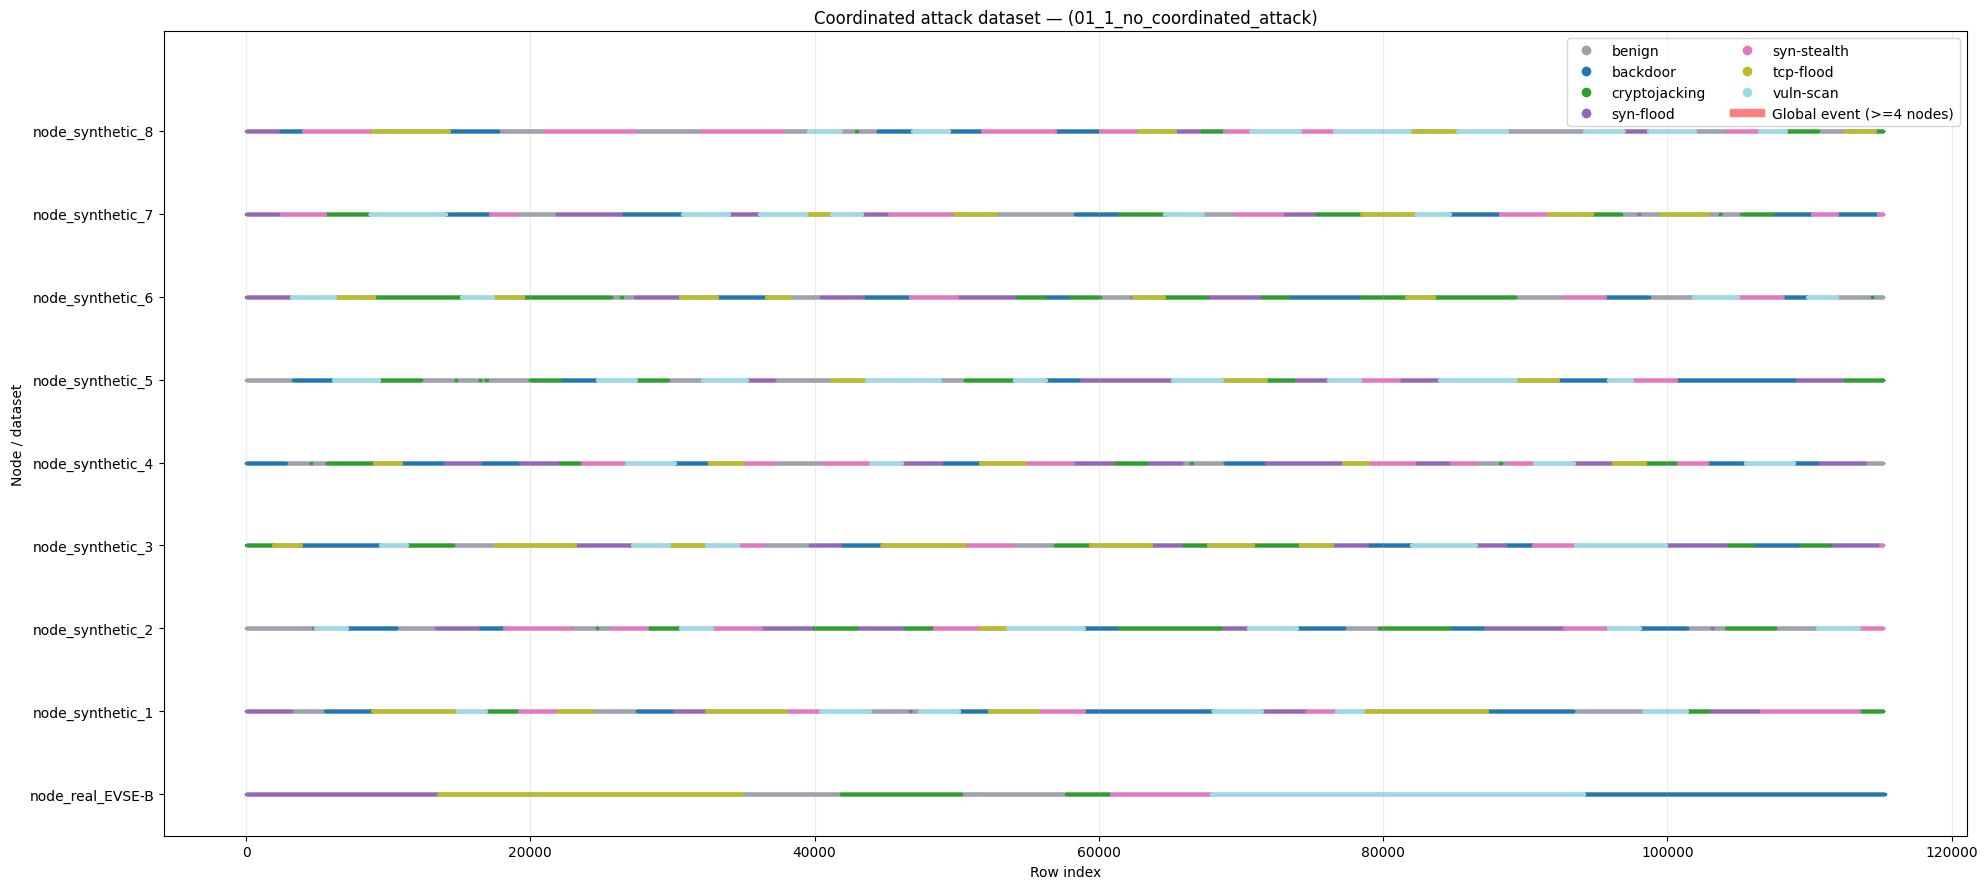

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/'

node_files = [
    'node_real_EVSE-B.csv',
    'node_synthetic_1.csv',
    'node_synthetic_2.csv',
    'node_synthetic_3.csv',
    'node_synthetic_4.csv',
    'node_synthetic_5.csv',
    'node_synthetic_6.csv',
    'node_synthetic_7.csv',
    'node_synthetic_8.csv',
]

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))
    df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()
    df['Label'] = df['Label'].astype(str).str.lower().str.strip()
    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = ['node_real_EVSE-B'] + [f'node_synthetic_{i}' for i in range(1, 9)]
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, 9.2)
ax.set_yticks(range(len(node_order)))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')
ax.set_title('Coordinated attack dataset — (01_1_no_coordinated_attack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.savefig(
    '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/attack_label_overview_no_coordinated_attack.png',
    dpi=150,
    bbox_inches='tight'
)
print("Plot saved.")

plt.tight_layout()
plt.show()

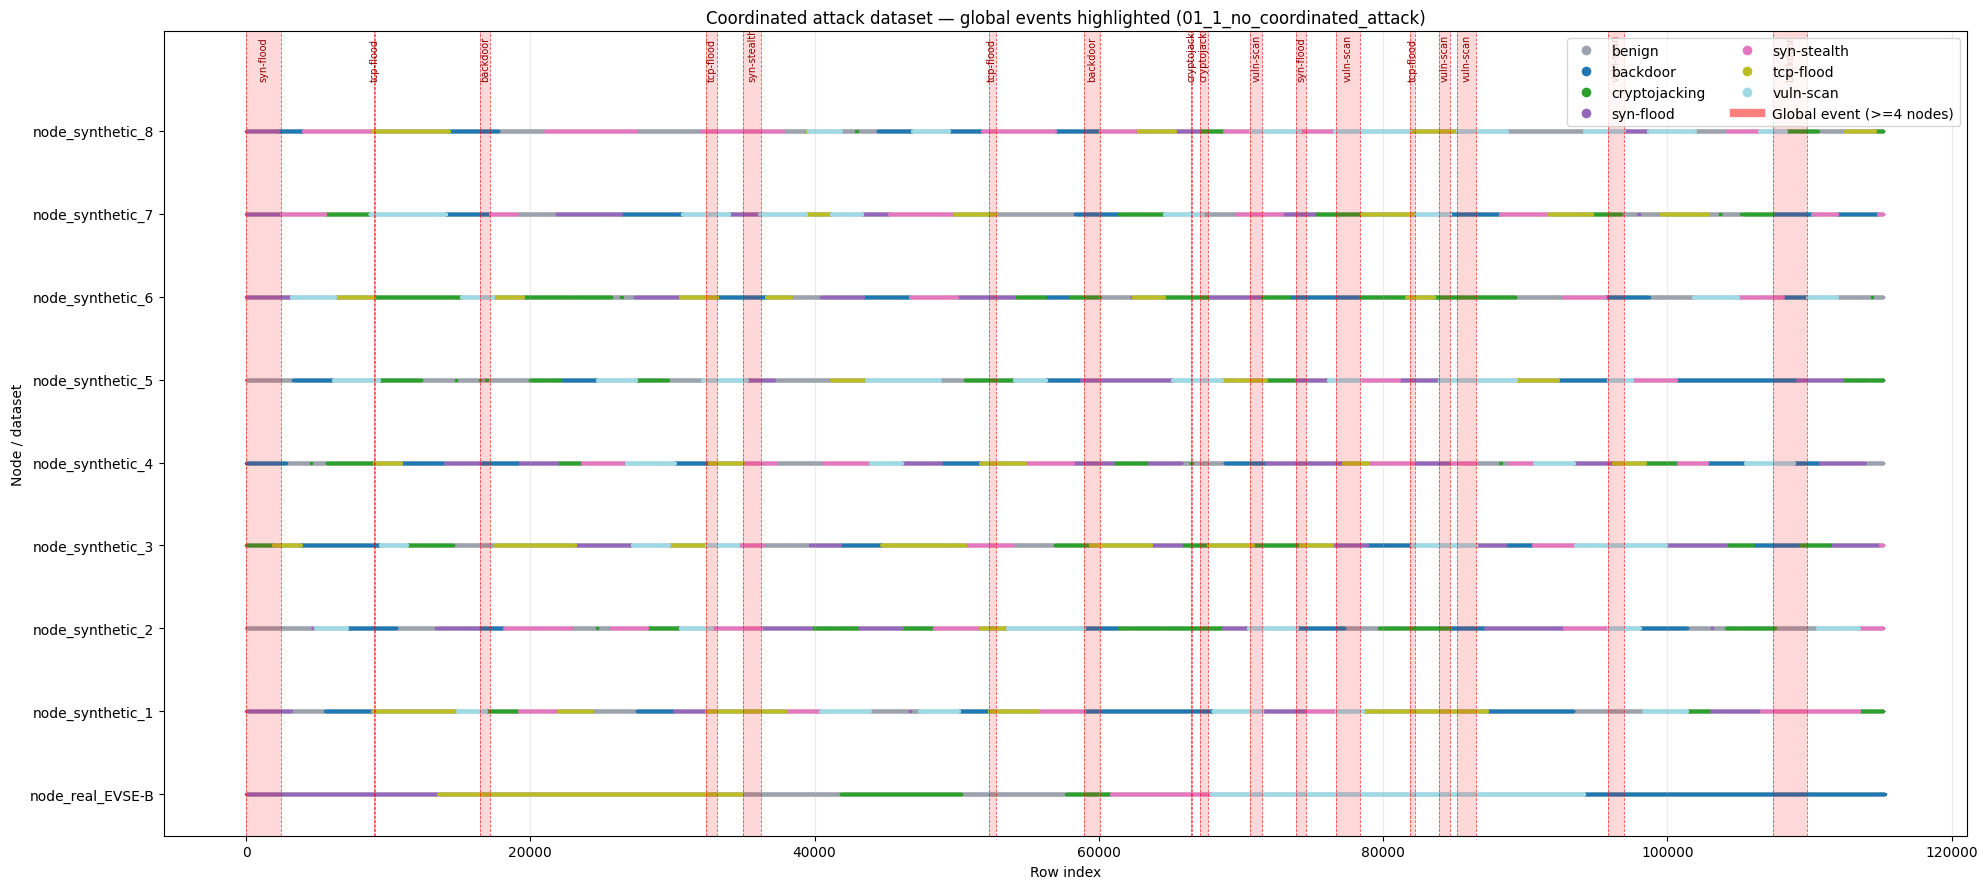

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/'

node_files = [
    'node_real_EVSE-B.csv',
    'node_synthetic_1.csv',
    'node_synthetic_2.csv',
    'node_synthetic_3.csv',
    'node_synthetic_4.csv',
    'node_synthetic_5.csv',
    'node_synthetic_6.csv',
    'node_synthetic_7.csv',
    'node_synthetic_8.csv',
]

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))
    df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()
    df['Label'] = df['Label'].astype(str).str.lower().str.strip()
    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = ['node_real_EVSE-B'] + [f'node_synthetic_{i}' for i in range(1, 9)]
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Detect windows where >= 4 nodes share the same attack type
# =============================================================================

pivot = all_df.pivot_table(
    index='row_idx',
    columns='node',
    values='attack_type',
    aggfunc='first'
)

attack_types_no_benign = [a for a in all_df['attack_type'].unique() if a != 'benign']

shared_rows = set()
for attack in attack_types_no_benign:
    count_per_row = (pivot == attack).sum(axis=1)
    matching = count_per_row[count_per_row >= 4].index.tolist()
    shared_rows.update(matching)

shared_rows = sorted(shared_rows)

def find_contiguous_ranges(rows, gap=1):
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges

ranges = find_contiguous_ranges(shared_rows, gap=2)

for (r_start, r_end) in ranges:
    ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
    ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

    # Print dominant attack label above each red span
    span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
    span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
    if not span_attacks.empty:
        dominant = span_attacks.value_counts().idxmax()
        mid_x    = (r_start + r_end) / 2
        ax.text(
            mid_x, 8.6,
            dominant,
            ha='center', va='bottom',
            fontsize=7,
            color='darkred',
            rotation=90,
            clip_on=True
        )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, 9.2)
ax.set_yticks(range(len(node_order)))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')
ax.set_title('Coordinated attack dataset — global events highlighted (01_1_no_coordinated_attack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# EVALUATION 2a — COORDINATED GLOBAL ATTACK DATASET
# When node synthetic_1 has syn-flood or tcp-flood, 4-7 other nodes
# get the same attack injected at the same row range.
# =============================================================================

import random

def inject_coordinated_attacks(
    node_dfs: dict,
    trigger_node: str,
    trigger_attacks: list,
    all_node_names: list,
    min_affected: int = 4,
    max_affected: int = 7,
    seed: int = 42
) -> dict:
    rng = np.random.default_rng(seed)
    result = {name: df.copy() for name, df in node_dfs.items()}

    trigger_df = result[trigger_node].copy()
    trigger_df['attack_lower'] = trigger_df['Attack'].str.lower().str.strip()

    # Find contiguous runs of the trigger attacks in trigger_node
    in_trigger = trigger_df['attack_lower'].isin([a.lower() for a in trigger_attacks])
    run_starts = []
    run_ends   = []
    in_run     = False

    for idx, val in in_trigger.items():
        if val and not in_run:
            run_start = idx
            in_run    = True
        elif not val and in_run:
            run_ends.append(idx - 1)
            run_starts.append(run_start)
            in_run = False
    if in_run:
        run_ends.append(len(trigger_df) - 1)
        run_starts.append(run_start)

    print(f"Found {len(run_starts)} trigger runs in {trigger_node}")

    other_nodes = [n for n in all_node_names if n != trigger_node]
    feature_cols = ['shunt_voltage', 'bus_voltage_V', 'current_mA',
                    'power_mW', 'State', 'Attack', 'Attack-Group', 'Label', 'interface']

    for run_idx, (r_start, r_end) in enumerate(zip(run_starts, run_ends)):
        # Pick 3-6 random other nodes to receive this attack
        n_affected = int(rng.integers(min_affected, max_affected + 1))
        n_affected = min(n_affected, len(other_nodes))
        affected   = [other_nodes[i] for i in rng.choice(
            len(other_nodes), size=n_affected, replace=False
        )]

        # Get the trigger rows as donor data
        donor_rows = trigger_df.loc[r_start:r_end, feature_cols]
        run_len    = len(donor_rows)

        for node_name in affected:
            target_df = result[node_name]
            # Clip to node length
            actual_end = min(r_end, len(target_df) - 1)
            actual_len = actual_end - r_start + 1
            if actual_len <= 0:
                continue
            result[node_name].loc[
                r_start:actual_end, feature_cols
            ] = donor_rows.iloc[:actual_len][feature_cols].values

        if run_idx % 10 == 0:
            print(f"  Run {run_idx+1}/{len(run_starts)}: "
                  f"rows {r_start}-{r_end} -> injected into {affected}")

    return result


# =============================================================================
# APPLY & SAVE
# =============================================================================

all_node_names = [f'synthetic_{i+1}' for i in range(N_SYNTHETIC_NODES)]

coordinated_nodes = inject_coordinated_attacks(
    node_dfs=synthetic_nodes,
    trigger_node='synthetic_1',
    trigger_attacks=['syn-flood', 'tcp-flood'],
    all_node_names=all_node_names,
    min_affected=3,
    max_affected=6,
    seed=42
)

OUTPUT_DIR_2A = '../datasets/CICEVSE2024/synthetic_nodes/01_2_coordinated_attack/'
os.makedirs(OUTPUT_DIR_2A, exist_ok=True)

# Save real node unchanged
df_power.to_csv(OUTPUT_DIR_2A + 'node_real_EVSE-B.csv', index=False)
print(f"Saved: node_real_EVSE-B.csv  [unchanged]")

for name, df in coordinated_nodes.items():
    path = OUTPUT_DIR_2A + f'node_{name}.csv'
    df.to_csv(path, index=False)
    print(f"Saved: node_{name}.csv  ({len(df):,} rows)")

print(f"\nAll nodes saved to: {OUTPUT_DIR_2A}")

Found 9 trigger runs in synthetic_1
  Run 1/9: rows 0-3136 -> injected into ['synthetic_5', 'synthetic_8', 'synthetic_7']
Saved: node_real_EVSE-B.csv  [unchanged]
Saved: node_synthetic_1.csv  (115,206 rows)
Saved: node_synthetic_2.csv  (115,206 rows)
Saved: node_synthetic_3.csv  (115,206 rows)
Saved: node_synthetic_4.csv  (115,206 rows)
Saved: node_synthetic_5.csv  (115,206 rows)
Saved: node_synthetic_6.csv  (115,206 rows)
Saved: node_synthetic_7.csv  (115,206 rows)
Saved: node_synthetic_8.csv  (115,206 rows)

All nodes saved to: ../datasets/CICEVSE2024/synthetic_nodes/01_2_coordinated_attack/


Plot saved.


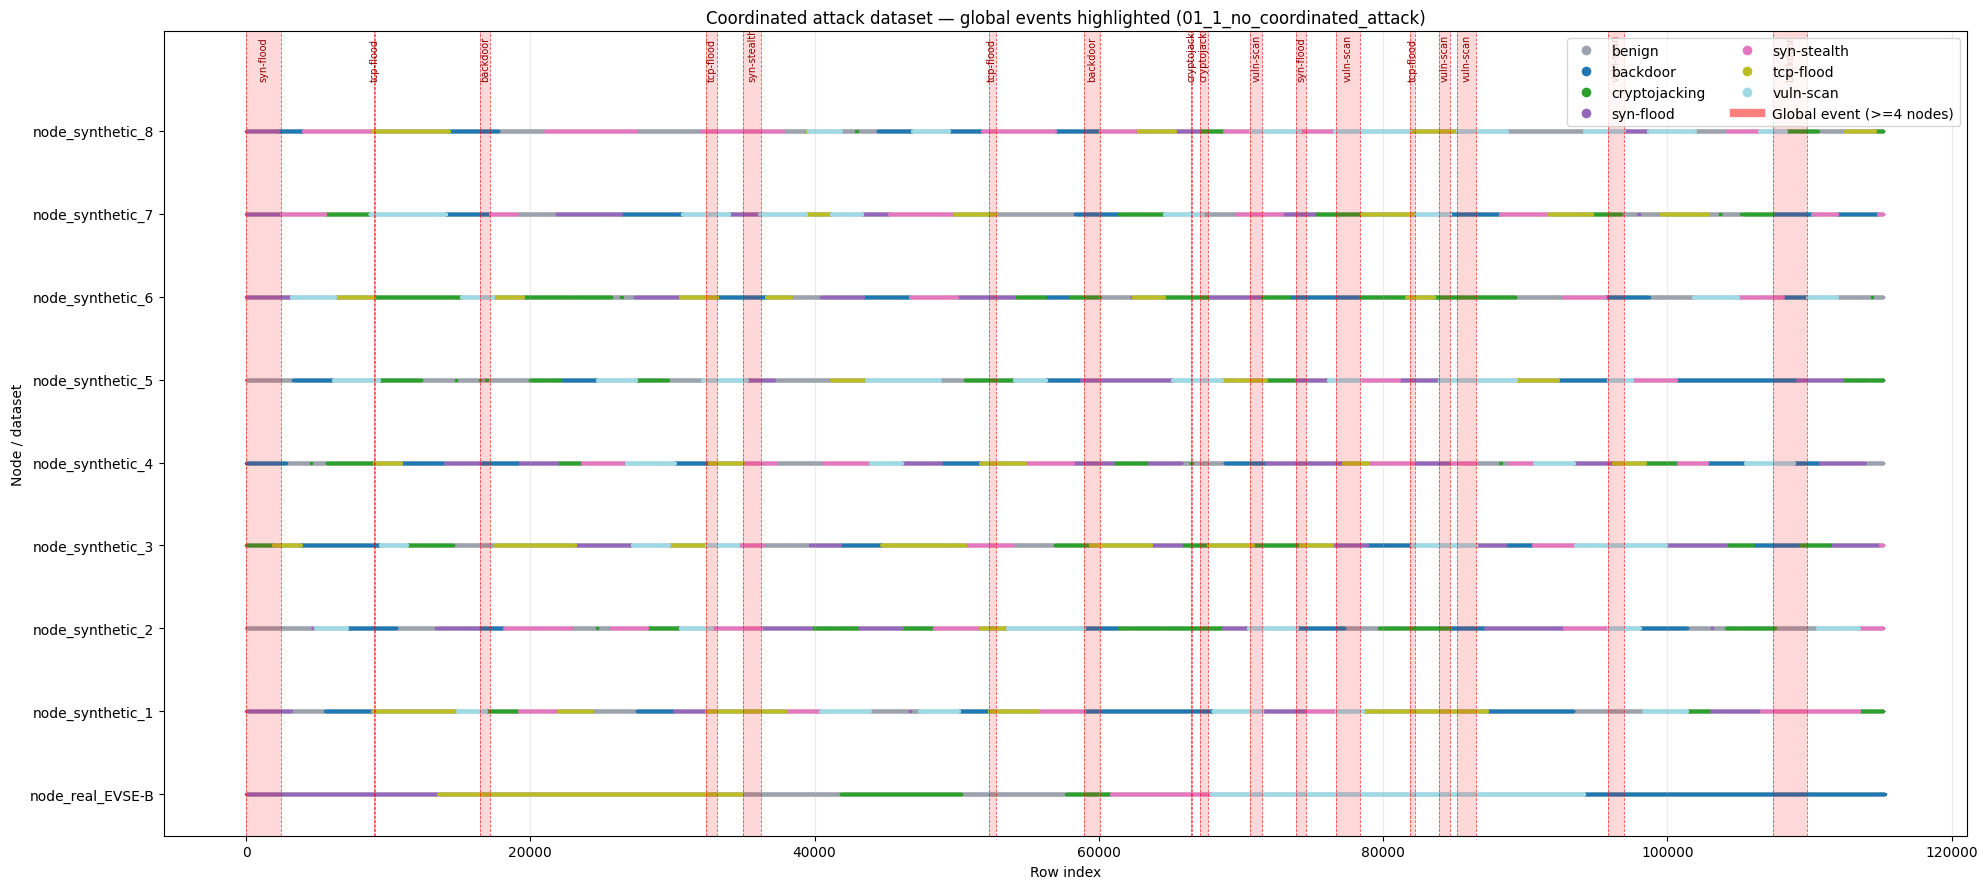

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/'

node_files = [
    'node_real_EVSE-B.csv',
    'node_synthetic_1.csv',
    'node_synthetic_2.csv',
    'node_synthetic_3.csv',
    'node_synthetic_4.csv',
    'node_synthetic_5.csv',
    'node_synthetic_6.csv',
    'node_synthetic_7.csv',
    'node_synthetic_8.csv',
]

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))
    df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()
    df['Label'] = df['Label'].astype(str).str.lower().str.strip()
    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = ['node_real_EVSE-B'] + [f'node_synthetic_{i}' for i in range(1, 9)]
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Detect windows where >= 4 nodes share the same attack type
# =============================================================================

pivot = all_df.pivot_table(
    index='row_idx',
    columns='node',
    values='attack_type',
    aggfunc='first'
)

attack_types_no_benign = [a for a in all_df['attack_type'].unique() if a != 'benign']

shared_rows = set()
for attack in attack_types_no_benign:
    count_per_row = (pivot == attack).sum(axis=1)
    matching = count_per_row[count_per_row >= 4].index.tolist()
    shared_rows.update(matching)

shared_rows = sorted(shared_rows)

def find_contiguous_ranges(rows, gap=1):
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges

ranges = find_contiguous_ranges(shared_rows, gap=2)

for (r_start, r_end) in ranges:
    ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
    ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

    span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
    span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
    if not span_attacks.empty:
        dominant = span_attacks.value_counts().idxmax()
        mid_x    = (r_start + r_end) / 2
        ax.text(
            mid_x, 8.6,
            dominant,
            ha='center', va='bottom',
            fontsize=7,
            color='darkred',
            rotation=90,
            clip_on=True
        )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, 9.2)
ax.set_yticks(range(len(node_order)))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')
ax.set_title('Coordinated attack dataset — global events highlighted (01_1_no_coordinated_attack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.tight_layout()

# --- Save plot before displaying ---
# Filename encodes: dataset variant, what is visualized, and the threshold used
plt.savefig(
    '../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coordinated_attack/attack_label_overview_no_coordinated_attack_global_events_min4nodes.png',
    dpi=150,
    bbox_inches='tight'
)
print("Plot saved.")

plt.show()

Found files: ['individualization_metadata.csv', 'node_real_EVSE-B.csv', 'node_synthetic_1_individualized.csv', 'node_synthetic_2_individualized.csv', 'node_synthetic_3_individualized.csv', 'node_synthetic_4_individualized.csv', 'node_synthetic_5_individualized.csv', 'node_synthetic_6_individualized.csv', 'node_synthetic_7_individualized.csv', 'node_synthetic_8_individualized.csv']
Plot saved.


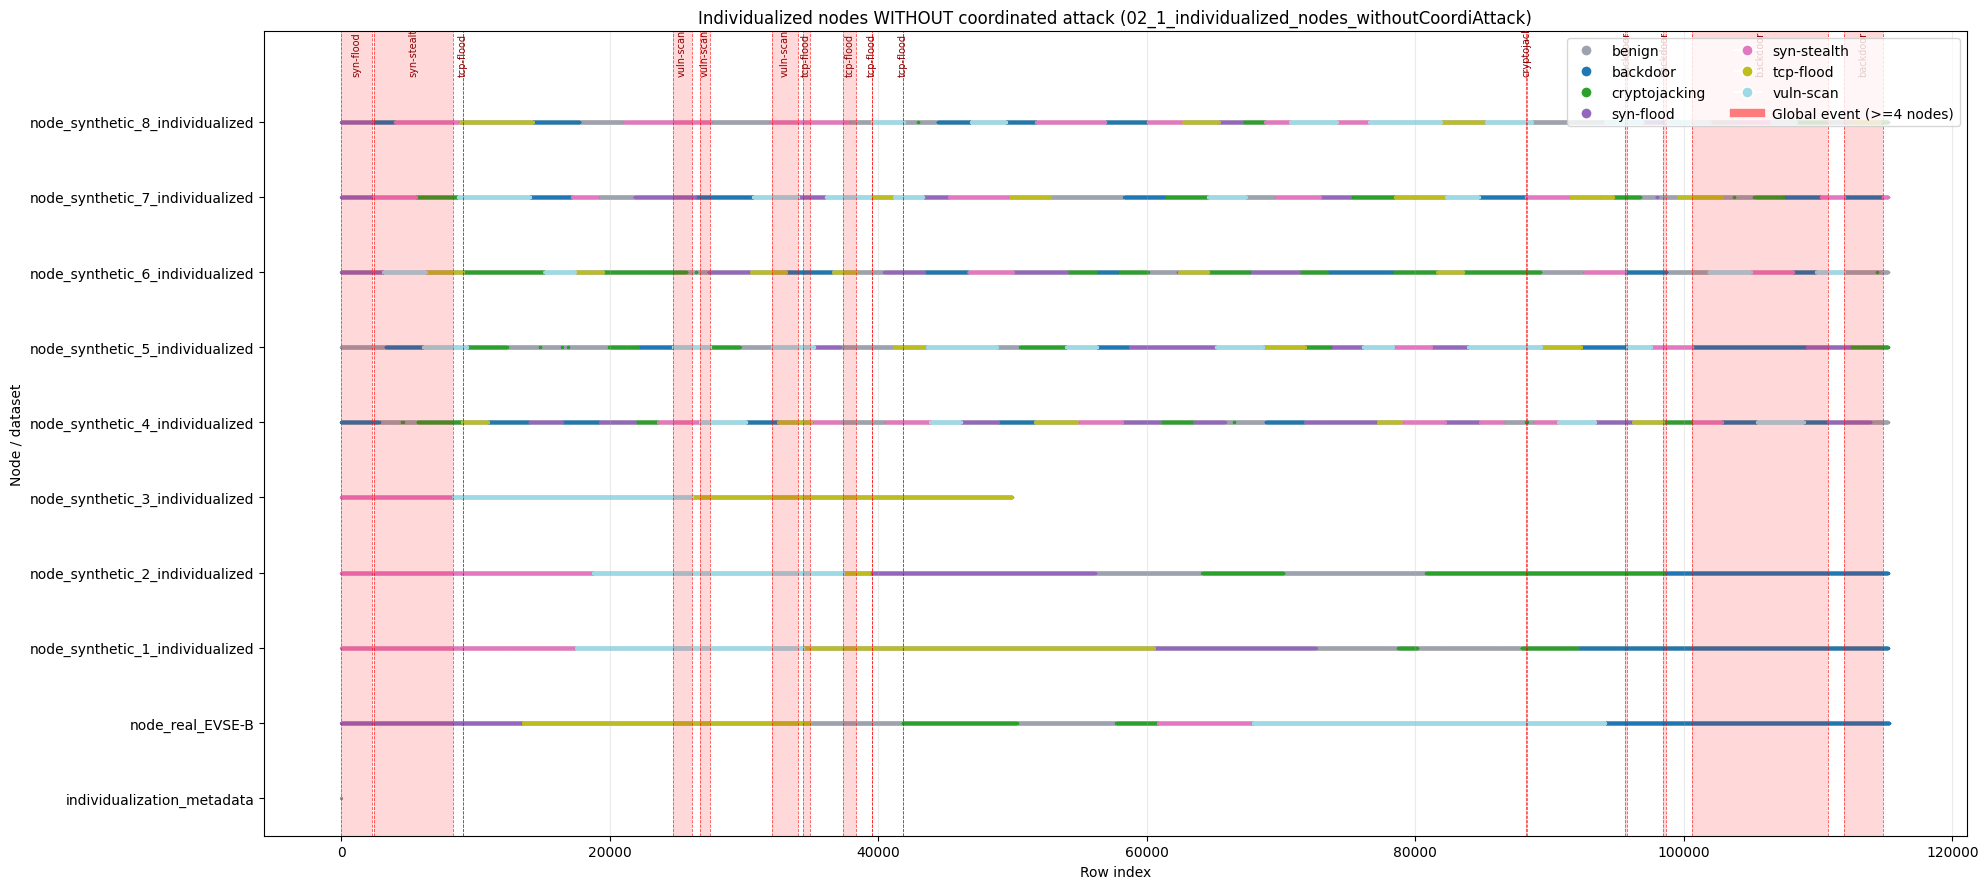

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Changed: 02_2_withCoordiAttack → 02_1_withoutCoordiAttack
base_dir = '../datasets/CICEVSE2024/synthetic_nodes/02_1_individualized_nodes_withoutCoordiAttack/'

node_files = sorted([os.path.basename(f) for f in glob.glob(os.path.join(base_dir, '*.csv'))])
print("Found files:", node_files)

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))

    if 'Label' not in df.columns:
        df['Label'] = 'benign'
    else:
        df['Label'] = df['Label'].astype(str).str.lower().str.strip()

    if 'Attack' not in df.columns:
        df['Attack'] = 'none'
    else:
        df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()

    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = sorted(all_df['node'].unique())
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

n_nodes = len(node_order)
fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Detect windows where >= 4 nodes share the same attack type
# =============================================================================

pivot = all_df.pivot_table(
    index='row_idx',
    columns='node',
    values='attack_type',
    aggfunc='first'
)

attack_types_no_benign = [a for a in all_df['attack_type'].unique() if a != 'benign']

shared_rows = set()
for attack in attack_types_no_benign:
    count_per_row = (pivot == attack).sum(axis=1)
    matching = count_per_row[count_per_row >= 4].index.tolist()
    shared_rows.update(matching)

shared_rows = sorted(shared_rows)

def find_contiguous_ranges(rows, gap=1):
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges

ranges = find_contiguous_ranges(shared_rows, gap=2)

for (r_start, r_end) in ranges:
    ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
    ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

    span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
    span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
    if not span_attacks.empty:
        dominant = span_attacks.value_counts().idxmax()
        mid_x    = (r_start + r_end) / 2
        ax.text(
            mid_x, n_nodes - 0.4,
            dominant,
            ha='center', va='bottom',
            fontsize=7,
            color='darkred',
            rotation=90,
            clip_on=True
        )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, n_nodes + 0.2)
ax.set_yticks(range(n_nodes))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')

# Changed: title updated to reflect WITHOUT coordinated attack variant
ax.set_title('Individualized nodes WITHOUT coordinated attack (02_1_individualized_nodes_withoutCoordiAttack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.tight_layout()

# Changed: save path and filename updated to withoutCoordiAttack
plt.savefig(
    '../datasets/CICEVSE2024/synthetic_nodes/02_1_individualized_nodes_withoutCoordiAttack/attack_label_overview_individualized_without_coordinated_attack_global_events_min4nodes.png',
    dpi=150,
    bbox_inches='tight'
)
print("Plot saved.")

plt.show()

Found files: ['node_real_EVSE-B.csv', 'node_synthetic_1.csv', 'node_synthetic_2.csv', 'node_synthetic_3.csv', 'node_synthetic_4.csv', 'node_synthetic_5.csv', 'node_synthetic_6.csv', 'node_synthetic_7.csv', 'node_synthetic_8.csv']
Plot saved.


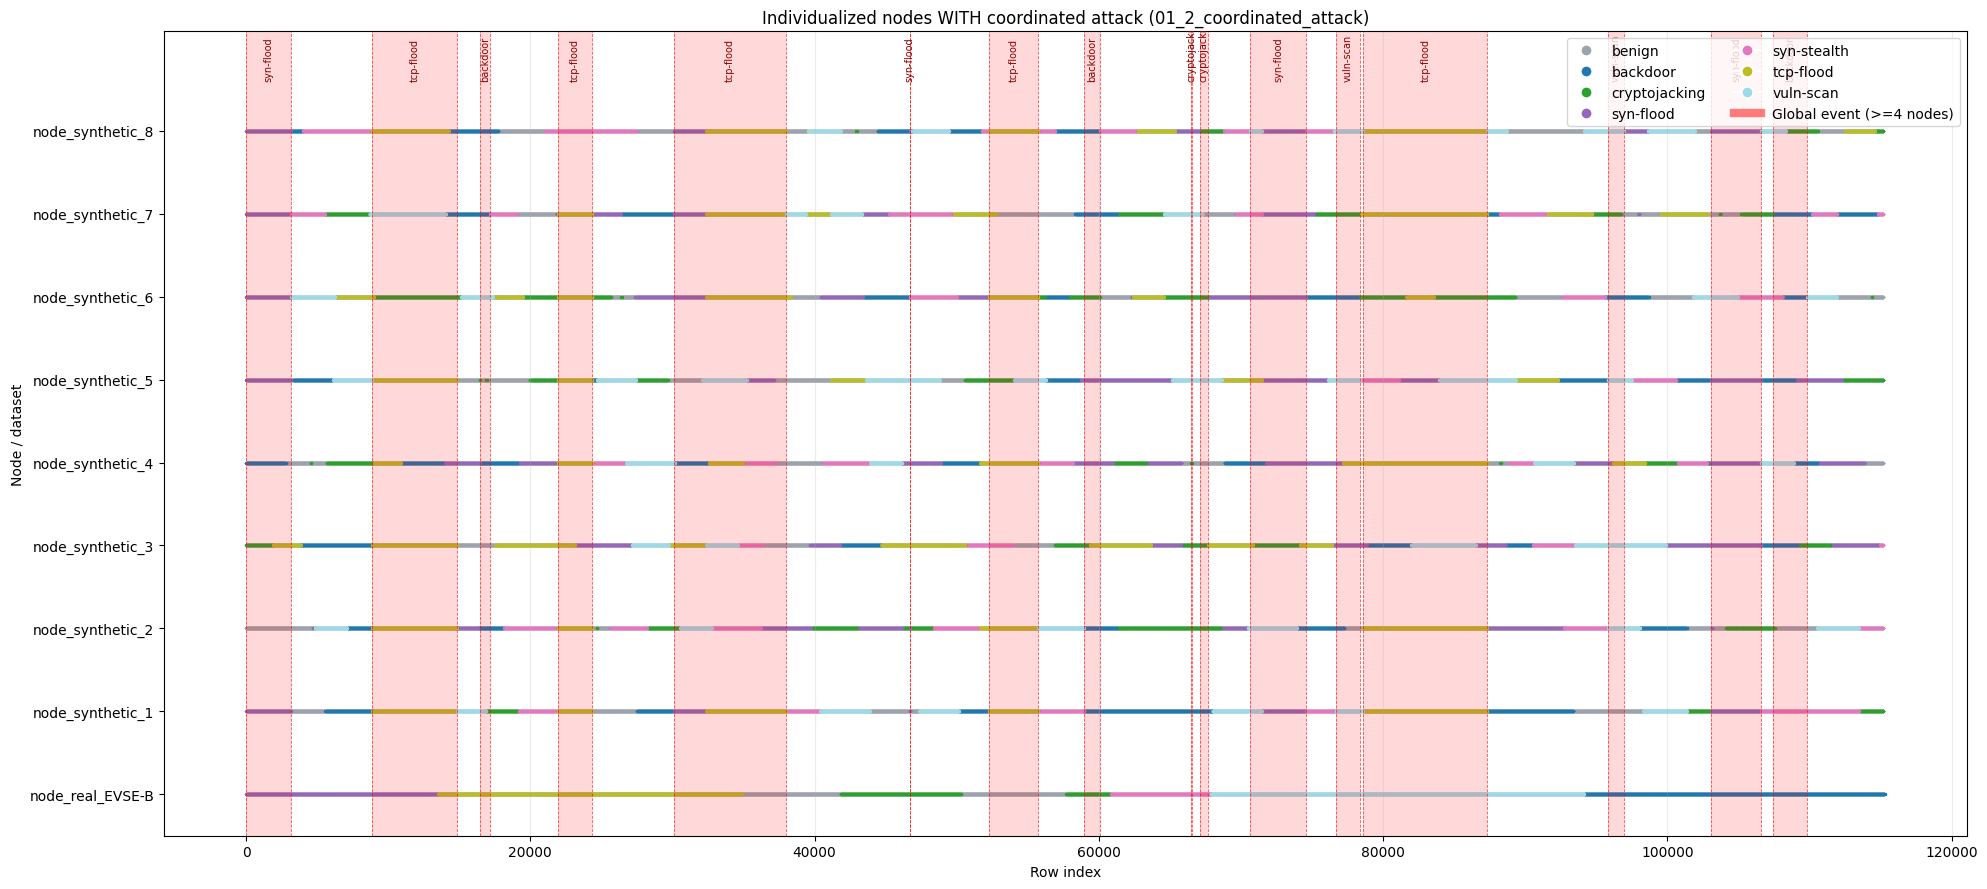

In [41]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Changed: 02_2_withCoordiAttack → 02_1_withoutCoordiAttack
base_dir = '../datasets/CICEVSE2024/synthetic_nodes/01_2_coordinated_attack/'

node_files = sorted([os.path.basename(f) for f in glob.glob(os.path.join(base_dir, '*.csv'))])
print("Found files:", node_files)

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))

    if 'Label' not in df.columns:
        df['Label'] = 'benign'
    else:
        df['Label'] = df['Label'].astype(str).str.lower().str.strip()

    if 'Attack' not in df.columns:
        df['Attack'] = 'none'
    else:
        df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()

    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = sorted(all_df['node'].unique())
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

n_nodes = len(node_order)
fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Detect windows where >= 4 nodes share the same attack type
# =============================================================================

pivot = all_df.pivot_table(
    index='row_idx',
    columns='node',
    values='attack_type',
    aggfunc='first'
)

attack_types_no_benign = [a for a in all_df['attack_type'].unique() if a != 'benign']

shared_rows = set()
for attack in attack_types_no_benign:
    count_per_row = (pivot == attack).sum(axis=1)
    matching = count_per_row[count_per_row >= 4].index.tolist()
    shared_rows.update(matching)

shared_rows = sorted(shared_rows)

def find_contiguous_ranges(rows, gap=1):
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges

ranges = find_contiguous_ranges(shared_rows, gap=2)

for (r_start, r_end) in ranges:
    ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
    ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

    span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
    span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
    if not span_attacks.empty:
        dominant = span_attacks.value_counts().idxmax()
        mid_x    = (r_start + r_end) / 2
        ax.text(
            mid_x, n_nodes - 0.4,
            dominant,
            ha='center', va='bottom',
            fontsize=7,
            color='darkred',
            rotation=90,
            clip_on=True
        )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, n_nodes + 0.2)
ax.set_yticks(range(n_nodes))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')

# Changed: title updated to reflect WITHOUT coordinated attack variant
ax.set_title('Individualized nodes WITH coordinated attack (01_2_coordinated_attack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.tight_layout()

# Changed: save path and filename updated to withoutCoordiAttack
plt.savefig(
    '../datasets/CICEVSE2024/synthetic_nodes/01_2_coordinated_attack/attack_label_overview_coordinated_attack_global_events_min4nodes.png',
    dpi=150,
    bbox_inches='tight'
)
print("Plot saved.")

plt.show()

In [30]:
import os
import pandas as pd

VERIFY_DIR = '../datasets/CICEVSE2024/synthetic_nodes/02_2_individualized_nodes_withCoordiAttack/'

# Load real node
df_real_verify = pd.read_csv(os.path.join(VERIFY_DIR, 'node_real_EVSE-B.csv'))

# Load all individualized synthetic nodes
synthetic_nodes_verify = {}
for f in sorted(os.listdir(VERIFY_DIR)):
    if f.startswith('node_synthetic') and f.endswith('.csv'):
        name = os.path.splitext(f)[0]
        synthetic_nodes_verify[name] = pd.read_csv(os.path.join(VERIFY_DIR, f))

# Verification table
print("=" * 70)
print("BLOCK BOOTSTRAP GROUPED — VERIFICATION (02_2 individualized)")
print("=" * 70)
print(f"{'Node':<35} {'Rows':>8} {'Attack%':>10} {'Benign%':>10} {'Unique runs':>12}")
print("-" * 70)

real_attack_pct = (df_real_verify['Label'] == 'attack').mean() * 100
real_benign_pct = (df_real_verify['Label'] == 'benign').mean() * 100
real_runs       = (df_real_verify['Attack'] != df_real_verify['Attack'].shift()).sum()
print(f"{'EVSE-B (real)':<35} {len(df_real_verify):>8,} "
      f"{real_attack_pct:>9.1f}% {real_benign_pct:>9.1f}% {real_runs:>12,}")
print("-" * 70)

for name, node_df in synthetic_nodes_verify.items():
    attack_pct = (node_df['Label'] == 'attack').mean() * 100
    benign_pct = (node_df['Label'] == 'benign').mean() * 100
    runs       = (node_df['Attack'] != node_df['Attack'].shift()).sum()
    print(f"{name:<35} {len(node_df):>8,} "
          f"{attack_pct:>9.1f}% {benign_pct:>9.1f}% {runs:>12,}")

print("=" * 70)

BLOCK BOOTSTRAP GROUPED — VERIFICATION (02_2 individualized)
Node                                    Rows    Attack%    Benign%  Unique runs
----------------------------------------------------------------------
EVSE-B (real)                        115,298      87.5%      12.5%            9
----------------------------------------------------------------------
node_synthetic_1_individualized      115,206      87.9%      12.1%            9
node_synthetic_2_individualized      115,206      88.5%      11.5%       12,785
node_synthetic_3_individualized      115,206      92.2%       7.8%        5,257
node_synthetic_4_individualized      115,206      89.5%      10.5%       13,065
node_synthetic_5_individualized      115,206      88.2%      11.8%       12,597
node_synthetic_6_individualized      115,206      86.3%      13.7%       11,360
node_synthetic_7_individualized      115,206      86.3%      13.7%        9,481
node_synthetic_8_individualized      115,206      83.9%      16.1%       22,2

Found files: ['individualization_metadata.csv', 'node_real_EVSE-B.csv', 'node_synthetic_1_individualized.csv', 'node_synthetic_2_individualized.csv', 'node_synthetic_3_individualized.csv', 'node_synthetic_4_individualized.csv', 'node_synthetic_5_individualized.csv', 'node_synthetic_6_individualized.csv', 'node_synthetic_7_individualized.csv', 'node_synthetic_8_individualized.csv']
Plot saved.


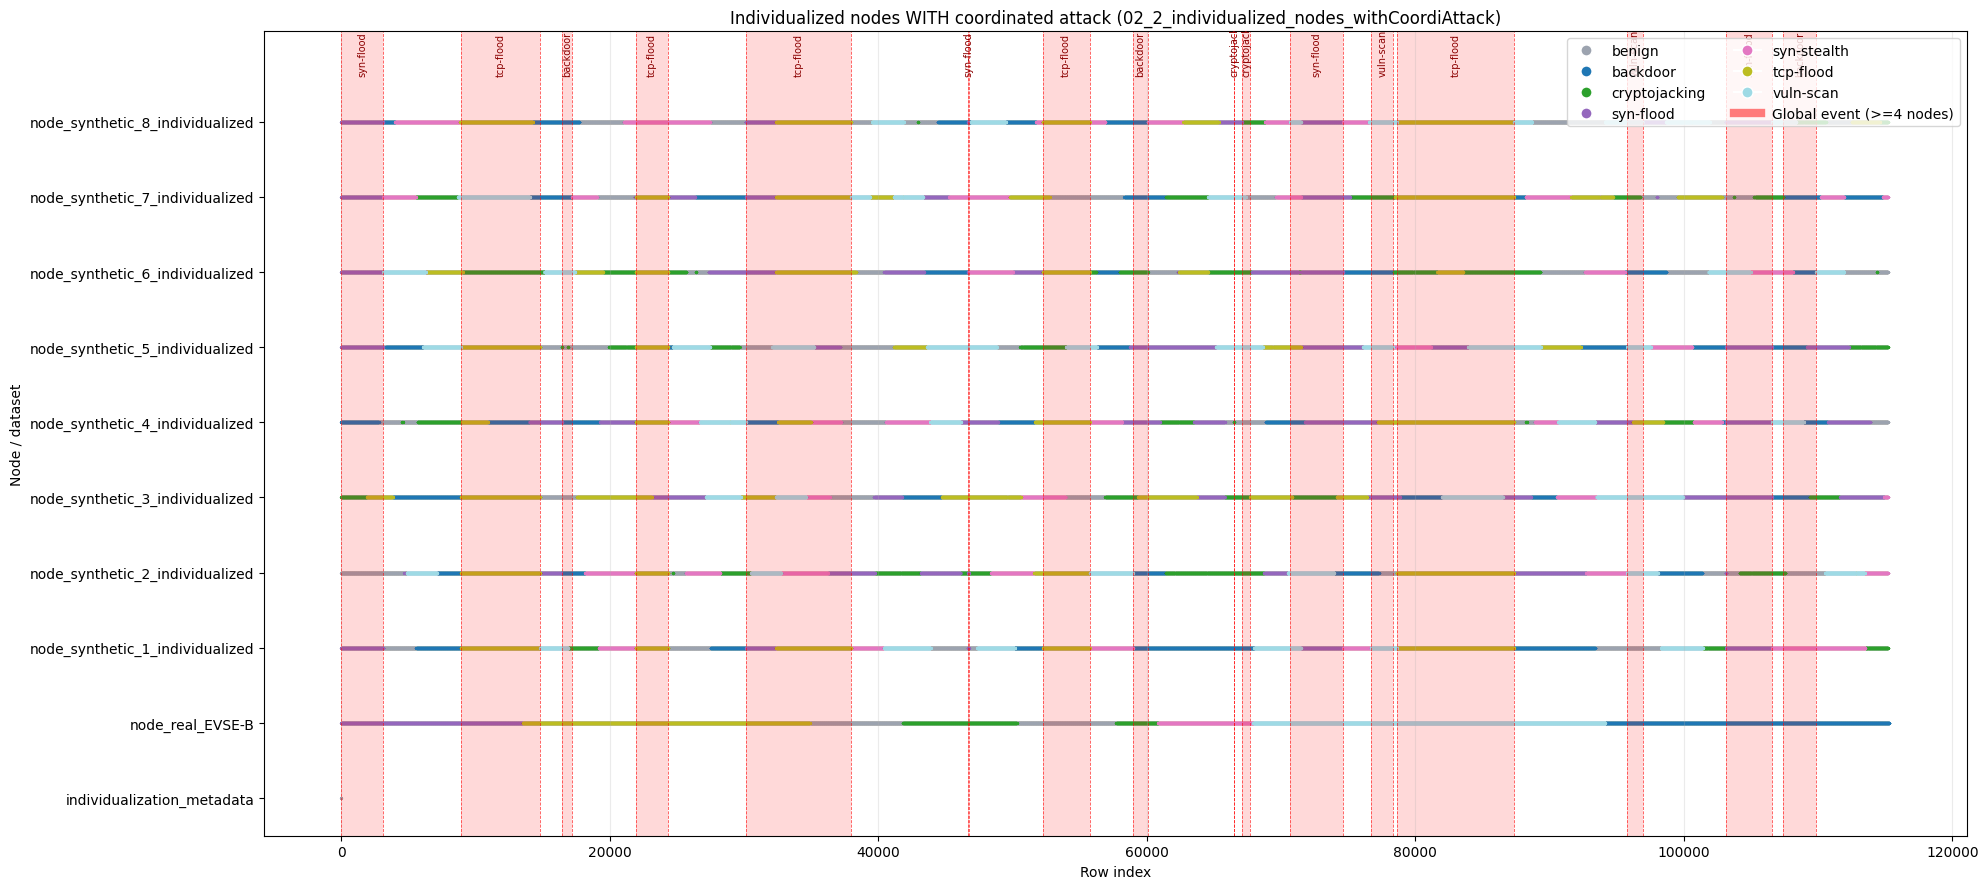

In [43]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = '../datasets/CICEVSE2024/synthetic_nodes/02_2_individualized_nodes_withCoordiAttack/'

node_files = sorted([os.path.basename(f) for f in glob.glob(os.path.join(base_dir, '*.csv'))])
print("Found files:", node_files)

frames = []

for file_name in node_files:
    path = os.path.join(base_dir, file_name)
    df = pd.read_csv(path)
    df['node'] = os.path.splitext(file_name)[0]
    df['row_idx'] = np.arange(len(df))

    if 'Label' not in df.columns:
        df['Label'] = 'benign'
    else:
        df['Label'] = df['Label'].astype(str).str.lower().str.strip()

    if 'Attack' not in df.columns:
        df['Attack'] = 'none'
    else:
        df['Attack'] = df['Attack'].astype(str).str.lower().str.strip()

    frames.append(df[['node', 'row_idx', 'Attack', 'Label']])

all_df = pd.concat(frames, ignore_index=True)

node_order = sorted(all_df['node'].unique())
node_to_y  = {node: i for i, node in enumerate(node_order)}
all_df['y'] = all_df['node'].map(node_to_y)

all_df['attack_type'] = np.where(
    all_df['Label'].eq('attack'),
    all_df['Attack'],
    'benign'
)

attack_types = sorted([x for x in all_df['attack_type'].unique() if x != 'benign'])

palette = plt.cm.tab20(np.linspace(0, 1, max(1, len(attack_types))))
colors  = {'benign': '#9ca3af'}
for i, attack in enumerate(attack_types):
    colors[attack] = palette[i]

n_nodes = len(node_order)
fig, ax = plt.subplots(figsize=(20, 9))

for attack_type, color in colors.items():
    subset = all_df[all_df['attack_type'] == attack_type]
    ax.scatter(
        subset['row_idx'],
        subset['y'],
        s=5,
        c=[color],
        alpha=0.65,
        linewidths=0,
    )

# =============================================================================
# Detect windows where >= 4 nodes share the same attack type
# =============================================================================

pivot = all_df.pivot_table(
    index='row_idx',
    columns='node',
    values='attack_type',
    aggfunc='first'
)

attack_types_no_benign = [a for a in all_df['attack_type'].unique() if a != 'benign']

shared_rows = set()
for attack in attack_types_no_benign:
    count_per_row = (pivot == attack).sum(axis=1)
    matching = count_per_row[count_per_row >= 4].index.tolist()
    shared_rows.update(matching)

shared_rows = sorted(shared_rows)

def find_contiguous_ranges(rows, gap=1):
    if not rows:
        return []
    ranges = []
    start = rows[0]
    prev  = rows[0]
    for r in rows[1:]:
        if r - prev > gap:
            ranges.append((start, prev))
            start = r
        prev = r
    ranges.append((start, prev))
    return ranges

ranges = find_contiguous_ranges(shared_rows, gap=2)

for (r_start, r_end) in ranges:
    ax.axvspan(r_start, r_end, color='red', alpha=0.15, linewidth=0)
    ax.axvline(r_start, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    ax.axvline(r_end,   color='red', linewidth=0.6, linestyle='--', alpha=0.7)

    span_data    = all_df[(all_df['row_idx'] >= r_start) & (all_df['row_idx'] <= r_end)]
    span_attacks = span_data[span_data['attack_type'] != 'benign']['attack_type']
    if not span_attacks.empty:
        dominant = span_attacks.value_counts().idxmax()
        mid_x    = (r_start + r_end) / 2
        ax.text(
            mid_x, n_nodes - 0.4,
            dominant,
            ha='center', va='bottom',
            fontsize=7,
            color='darkred',
            rotation=90,
            clip_on=True
        )

# =============================================================================
# Legend, labels, layout
# =============================================================================

ax.set_ylim(-0.5, n_nodes + 0.2)
ax.set_yticks(range(n_nodes))
ax.set_yticklabels(node_order)
ax.set_xlabel('Row index')
ax.set_ylabel('Node / dataset')

# Title fix: was incorrectly labeled WITHOUT — this is the WITH coordinated attack variant
ax.set_title('Individualized nodes WITH coordinated attack (02_2_individualized_nodes_withCoordiAttack)')
ax.grid(axis='x', alpha=0.25)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='benign',
           markerfacecolor=colors['benign'], markersize=8)
]
for attack in attack_types:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=attack,
               markerfacecolor=colors[attack], markersize=8)
    )
legend_handles.append(
    Line2D([0], [0], color='red', alpha=0.5, linewidth=6, label='Global event (>=4 nodes)')
)

ax.legend(handles=legend_handles, loc='upper right', ncol=2)

plt.tight_layout()

# --- Save plot before displaying ---
plt.savefig(
    '../datasets/CICEVSE2024/synthetic_nodes/02_2_individualized_nodes_withCoordiAttack/attack_label_overview_individualized_with_coordinated_attack_global_events_min4nodes.png',
    dpi=150,
    bbox_inches='tight'
)
print("Plot saved.")

plt.show()

In [26]:
txt = '''warum genau so viele zeit blöcke wie von mir ausgewählt hintereinander?
warum ist syn-flood und tcp-flood global der rest aber nicht? (naja ist ja eig. egal welcher angriff gloabl ist oder nciht, soll ja nur beweisen das er es könnte falls es so ist die anderen angirffe aber torztdme noch erkennt obwohl sie einzeltn auf jeden Node sind
warum 4 bis 7 andere knoten und nicht eine andere anzahl?

Q1: Why 10–20 blocks (30–60 min)?
Mirrors real EVSE-B behavior where attacks last 30–120 min. Naive per-block draws would fragment labels every 3 min, making global events undetectable.

Q2: Why SYN-flood and TCP-flood as global events?
Just a bootstrap artifact — they dominate the block pool so they coincidentally overlap across nodes. The specific attack type is irrelevant; what matters is proving the system detects coordinated events and still catches the individual ones.

Q3: Why 4–7 compromised nodes?
Covers the tipping point ran
=== Processing dataset: without_global_attack ===
Input dir:  ../datasets/CICEVSE2024/synthetic_nodes/01_1_no_coo
print(txt)


warum genau so viele zeit blöcke wie von mir ausgewählt hintereinander?
warum ist syn-flood und tcp-flood global der rest aber nicht? (naja ist ja eig. egal welcher angriff gloabl ist oder nciht, soll ja nur beweisen das er es könnte falls es so ist die anderen angirffe aber torztdme noch erkennt obwohl sie einzeltn auf jeden Node sind
warum 4 bis 7 andere knoten und nicht eine andere anzahl?

Q1: Why 10–20 blocks (30–60 min)?
Mirrors real EVSE-B behavior where attacks last 30–120 min. Naive per-block draws would fragment labels every 3 min, making global events undetectable.

Q2: Why SYN-flood and TCP-flood as global events?
Just a bootstrap artifact — they dominate the block pool so they coincidentally overlap across nodes. The specific attack type is irrelevant; what matters is proving the system detects coordinated events and still catches the individual ones.

Q3: Why 4–7 compromised nodes?
Covers the tipping point range (4:5 near-even → 7:2 supermajority) needed to empirically te